In [2]:
import gdsfactory as gf
from ekin_master_die import xs_ekn300_te_IMGREV
gf.gpdk.PDK.activate()

xs_heater_wire = gf.get_cross_section(xs_ekn300_te_IMGREV, width = 2, width_trench = 1, layer = 'M3', radius = 2, layer_trench = (3,6))

heater = gf.components.wire_corner45_straight(cross_section=xs_heater_wire, radius=2 ).show()

/home/sadilek/Dev/mesaplus/mesapdk-lab/.venv/lib/python3.13/site-packages/kfactory/decorators.py:406: UserWarning: `width` overrides `start_width`. Use only `start_width` going forward.
  cell = f(**params)  # type: ignore[call-arg]


In [ ]:
via1 = gf.c.via(size=(3,3))

via_stack_heater = gf.c.via_stack(size=(25,25), layers=('HEATER', 'M1', 'M2'), correct_size=False)

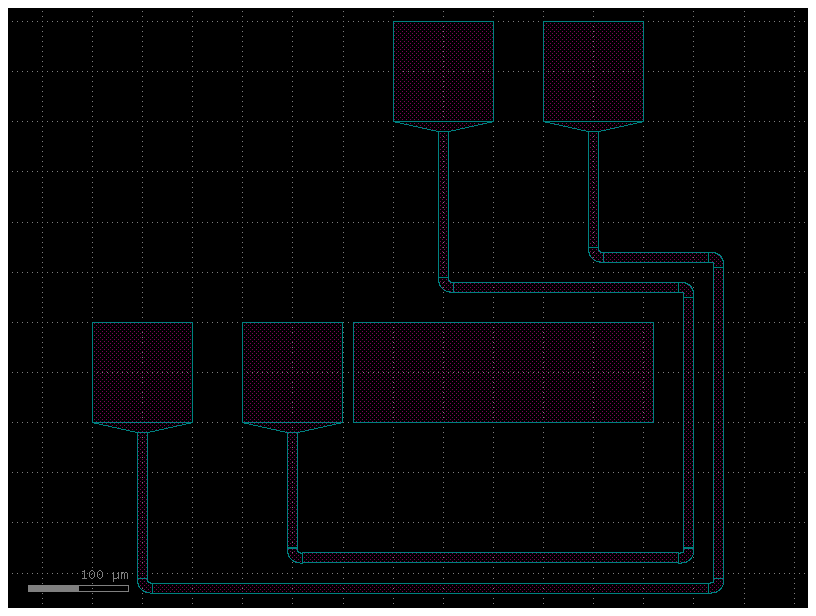

In [3]:
import gdsfactory as gf

c = gf.Component()
columns = 2
ptop = c << gf.components.pad_array(columns=columns, port_orientation=270)
pbot = c << gf.components.pad_array(port_orientation=270, columns=columns)
ptop.movex(300)
ptop.movey(300)

obstacle = c << gf.c.rectangle(size=(300, 100), layer="M3", centered=True)
obstacle.ymin = pbot.ymax - 100
obstacle.xmin = pbot.xmax + 10


routes = gf.routing.route_bundle(
    c,
    pbot.ports,
    ptop.ports,
    start_straight_length=100,
    separation=20,
    cross_section="metal_routing",
    bboxes=[
        obstacle.bbox().enlarge(10), # Otherwise you need to enlarge the bbox by 10 um.
        pbot.bbox(),
        ptop.bbox(),
    ],  
    sort_ports=True,
)

c